In [34]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib

In [35]:
df=pd.read_csv('./data/train.csv')
df.dropna(inplace=True)
print(df.head())

   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  pixel782  pixel783  
0         0         0         

In [36]:
df.shape

(42000, 785)

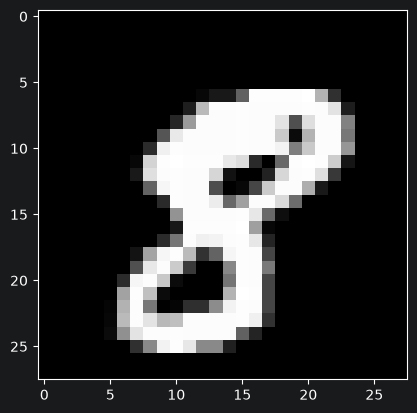

In [37]:
img_digit=df.iloc[10,1:].values.reshape(-1,28)
plt.imshow(img_digit,cmap='gray')
plt.show()

In [38]:
# 划分数据集
X=df.drop('label',axis=1)
y=df['label']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(x_train.shape,y_train.shape,x_test.shape,y_test.shape)

(33600, 784) (33600,) (8400, 784) (8400,)


In [39]:
# 特征工程
scaler=MinMaxScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [43]:
# 定义模型
model=LogisticRegression(max_iter=1000)

In [44]:
# 模型训练
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [46]:
# 模型评估
# 模型评估
accuracy1=model.score(x_train,y_train)
print(accuracy1)
accuracy=model.score(x_test,y_test)
print(accuracy)

0.9463690476190476
0.9191666666666667


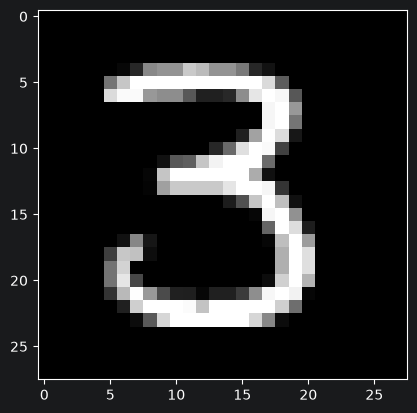

[3]


In [60]:
# 新数据预测
img_digit = x_test[123]
img_show=img_digit.reshape(28,28)
plt.imshow(img_show,cmap='gray')
plt.show()
y_pred=img_digit.reshape(1,-1)
print(model.predict(y_pred))
